In [10]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/behavior-aware-bms

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/behavior-aware-bms


In [11]:
df = pd.read_csv(
    "/content/drive/MyDrive/behavior-aware-bms/data/processed/nasa/nasa_analysis_with_soc.csv"
)

print(df.shape)

df.head()

(7282946, 20)


,battery_id,cycle,timestamp,voltage_v,current_a,temperature_c,capacity_ah,soc,soh,power_w,mode_guess,source,source_file,fast_charge_event,deep_discharge_event,high_temp_event,aggressive_discharge_event,high_soc_duration,raw_stress_score,stress_score
0,B0005,0,0 days 00:00:00,3.873017,-0.001201,24.655358,NaN,90.000000,NaN,-0.004650,idle,nasa,05121.csv,0,0,0,0,1,0.15,15.0
1,B0005,0,0 days 00:00:02.532000,3.479394,-4.030268,24.666480,NaN,89.858269,NaN,-14.022890,discharge,nasa,05121.csv,0,0,0,1,1,0.25,25.0
2,B0005,0,0 days 00:00:05.500000,4.000588,1.512731,24.675394,NaN,89.920627,NaN,6.051812,charge,nasa,05121.csv,1,0,0,0,1,0.45,45.0
3,B0005,0,0 days 00:00:08.344000,4.012395,1.509063,24.693865,NaN,89.980235,NaN,6.054958,charge,nasa,05121.csv,1,0,0,0,1,0.45,45.0
4,B0005,0,0 days 00:00:11.125000,4.019708,1.511318,24.705069,NaN,90.038610,NaN,6.075058,charge,nasa,05121.csv,1,0,0,0,1,0.45,45.0


In [12]:
features = [
    'voltage_v',
    'current_a',
    'temperature_c',
    'power_w',
    'fast_charge_event',
    'deep_discharge_event',
    'high_temp_event',
    'aggressive_discharge_event',
    'high_soc_duration',
    'soc'
]

target = 'stress_score'

model_df = df[features + [target]].dropna()

print(model_df.shape)

(7282689, 11)


In [13]:
sample_df = model_df.sample(
    n=200000,
    random_state=42
)

print(sample_df.shape)

(200000, 11)


In [14]:
X = sample_df[features]
y = sample_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(160000, 10)
(40000, 10)


In [16]:
model = HistGradientBoostingRegressor(
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [17]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.00230698224879598
RMSE: 0.057411714146639585
R²  : 0.9999802118047899


In [18]:
results = X_test.copy()

results["actual"] = y_test.values
results["predicted"] = y_pred

results["error"] = (
    results["actual"] - results["predicted"]
)

results["abs_error"] = results["error"].abs()

results.head()

,voltage_v,current_a,temperature_c,power_w,fast_charge_event,deep_discharge_event,high_temp_event,aggressive_discharge_event,high_soc_duration,soc,actual,predicted,error,abs_error
567895,3.567390,0.000236,36.259631,0.000842,0,0,0,0,0,24.958249,0.0,0.003345,-0.003345,0.003345
1857441,4.046039,1.517868,23.821649,6.141355,1,0,0,0,1,100.000000,45.0,44.998641,0.001359,0.001359
5683142,4.180408,1.513732,7.973407,6.328015,1,0,0,0,1,100.000000,45.0,44.998641,0.001359,0.001359
3612297,4.197926,0.061560,25.058160,0.258424,0,0,0,0,1,100.000000,15.0,15.000325,-0.000325,0.000325
3308620,3.670520,-0.004059,40.023472,-0.014898,0,0,1,0,0,14.895512,25.0,24.990390,0.009610,0.009610


In [19]:
worst_cases = results.sort_values(
    "abs_error",
    ascending=False
)

worst_cases.head(20)

,voltage_v,current_a,temperature_c,power_w,fast_charge_event,deep_discharge_event,high_temp_event,aggressive_discharge_event,high_soc_duration,soc,actual,predicted,error,abs_error
4239983,2.776000,-0.003957,48.071253,-0.010985,0,1,1,0,1,90.000000,60.0,50.234826,9.765174,9.765174
4356202,3.117199,1.490644,47.416223,4.646634,0,1,1,0,1,90.067882,60.0,57.015521,2.984479,2.984479
1025895,3.068580,0.000450,41.106718,0.001381,0,1,1,0,0,23.038528,45.0,47.340047,-2.340047,2.340047
2228885,2.918648,-0.000878,40.112688,-0.002562,0,1,1,0,0,0.000000,45.0,43.490684,1.509316,1.509316
3276208,2.657979,-4.026803,45.782805,-10.703157,0,1,1,1,0,67.250836,55.0,56.453559,-1.453559,1.453559
2643924,3.574298,1.515412,58.302392,5.416533,1,0,1,0,1,89.943072,70.0,68.768896,1.231104,1.231104
2472574,3.025987,0.001003,32.044609,0.003035,0,1,0,0,1,90.000000,35.0,36.218650,-1.218650,1.218650
4305582,3.174489,-4.030288,54.152792,-12.794107,0,1,1,1,0,70.575894,55.0,56.155215,-1.155215,1.155215
4221159,3.525544,1.513907,47.650578,5.337347,1,0,1,0,1,91.670030,70.0,70.857117,-0.857117,0.857117
4297331,3.459100,1.515751,53.136757,5.243136,1,0,1,0,1,90.869928,70.0,70.806493,-0.806493,0.806493


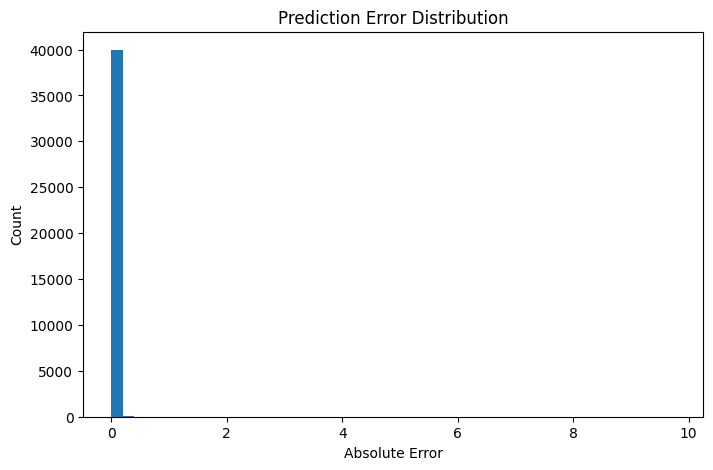

In [20]:
plt.figure(figsize=(8,5))

plt.hist(
    results["abs_error"],
    bins=50
)

plt.xlabel("Absolute Error")
plt.ylabel("Count")
plt.title("Prediction Error Distribution")

plt.show()

In [21]:
temp_analysis = results.copy()

temp_analysis["temp_group"] = pd.cut(
    temp_analysis["temperature_c"],
    bins=5
)

temp_summary = temp_analysis.groupby(
    "temp_group"
)["abs_error"].mean()

temp_summary

/tmp/ipykernel_8885/925360697.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_summary = temp_analysis.groupby(


,abs_error
temp_group,
"(2.936, 14.929]",0.001015
"(14.929, 26.862]",0.000527
"(26.862, 38.796]",0.002382
"(38.796, 50.729]",0.010858
"(50.729, 62.662]",0.037863


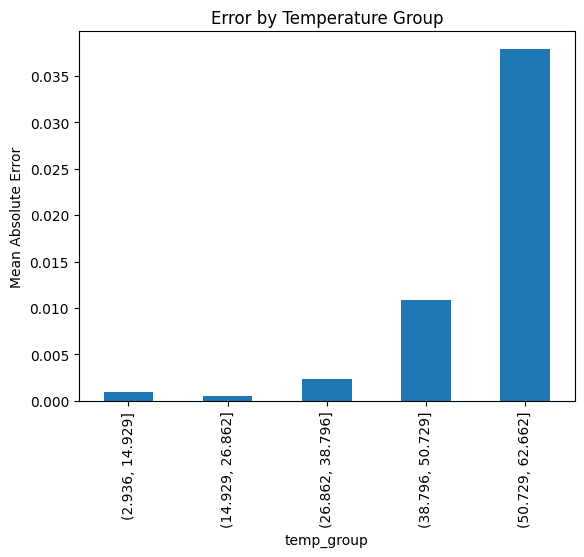

In [22]:
temp_summary.plot(
    kind="bar"
)

plt.ylabel("Mean Absolute Error")
plt.title("Error by Temperature Group")

plt.show()

In [23]:
results.groupby(
    "fast_charge_event"
)["abs_error"].mean()

,abs_error
fast_charge_event,
0,0.001991
1,0.005098


In [24]:
results.groupby(
    "aggressive_discharge_event"
)["abs_error"].mean()

,abs_error
aggressive_discharge_event,
0,0.001909
1,0.012797


In [25]:
results["stress_group"] = pd.cut(
    results["actual"],
    bins=[0,30,60,100],
    labels=["Low","Medium","High"]
)

results.groupby(
    "stress_group"
)["abs_error"].mean()

/tmp/ipykernel_8885/509569354.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  results.groupby(


,abs_error
stress_group,
Low,0.000733
Medium,0.007287
High,0.019557


In [26]:
import os

os.makedirs(
    "/content/drive/MyDrive/behavior-aware-bms/reports/metrics",
    exist_ok=True
)

summary = pd.DataFrame({
    "metric":["MAE","RMSE","R2"],
    "value":[mae, rmse, r2]
})

summary.to_csv(
    "/content/drive/MyDrive/behavior-aware-bms/reports/metrics/error_analysis_metrics.csv",
    index=False
)

print("Saved.")

Saved.


In [29]:
!find /content/drive/MyDrive/behavior-aware-bms/data/features -type f 2>/dev/null
!find /content/drive/MyDrive/behavior-aware-bms/docs -type f | sort
!find /content/drive/MyDrive/behavior-aware-bms/reports -type f | sort
!find /content/drive -iname "*calce*" | head -100
!find /content/drive -iname "*stanford*" | head -100

/content/drive/MyDrive/behavior-aware-bms/docs/acceptance_checklist_day3.md
/content/drive/MyDrive/behavior-aware-bms/docs/code_review_notes_day3.md
/content/drive/MyDrive/behavior-aware-bms/docs/data_contract_day3.md
/content/drive/MyDrive/behavior-aware-bms/docs/data_dictionary.md
/content/drive/MyDrive/behavior-aware-bms/docs/day3_delivery_report.md
/content/drive/MyDrive/behavior-aware-bms/docs/day3_notes.md
/content/drive/MyDrive/behavior-aware-bms/docs/day5_team_update.md
/content/drive/MyDrive/behavior-aware-bms/docs/team_update_day3.md
/content/drive/MyDrive/behavior-aware-bms/docs/week2_backlog.md
/content/drive/MyDrive/behavior-aware-bms/reports/metrics/error_analysis_metrics.csv
/content/drive/MyDrive/behavior-aware-bms/reports/weekly/week1_minutes.md
/content/drive/MyDrive/behavior-aware-bms/reports/weekly/week1_review/audit_summary.json
/content/drive/MyDrive/behavior-aware-bms/reports/weekly/week1_review/figures/01_file_coverage_by_stage.png
/content/drive/MyDrive/behavio

In [30]:
!find /content/drive/MyDrive/behavior-aware-bms/notebooks -type f | sort


/content/drive/MyDrive/behavior-aware-bms/notebooks/03_calce_preprocessing.ipynb
/content/drive/MyDrive/behavior-aware-bms/notebooks/BMS_Project_Setup.ipynb
/content/drive/MyDrive/behavior-aware-bms/notebooks/error_analysis.ipynb
/content/drive/MyDrive/behavior-aware-bms/notebooks/nasa_preproc


In [31]:
cd /content/drive/MyDrive/behavior-aware-bms

/content/drive/MyDrive/behavior-aware-bms


In [32]:
!git status

Refresh index: 100% (62/62), done.
On branch main
Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/BMS_Project_Setup.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	data/raw/nasa/cleaned_dataset/
	models/
	notebooks/error_analysis.ipynb
	notebooks/nasa_preproc
	reports/metrics/

no changes added to commit (use "git add" and/or "git commit -a")


In [34]:
%%writefile docs/modeling_protocol.md
# V1 Modeling Scope

## Dataset

NASA Battery Dataset

## Prediction Target

stress_score

## Features

- voltage_v
- current_a
- temperature_c
- power_w
- soc
- fast_charge_event
- deep_discharge_event
- high_temp_event
- aggressive_discharge_event
- high_soc_duration

## Models

- HistGradientBoostingRegressor
- RandomForestRegressor

## Scope Freeze

CALCE and Stanford datasets are excluded from V1 because they are not yet integrated into the preprocessing pipeline.

Future versions will use CALCE and Stanford for SOH prediction and cross-dataset validation.

Writing docs/modeling_protocol.md


In [35]:
!cat docs/modeling_protocol.md

# V1 Modeling Scope

## Dataset

NASA Battery Dataset

## Prediction Target

stress_score

## Features

- voltage_v
- current_a
- temperature_c
- power_w
- soc
- fast_charge_event
- deep_discharge_event
- high_temp_event
- aggressive_discharge_event
- high_soc_duration

## Models

- HistGradientBoostingRegressor
- RandomForestRegressor

## Scope Freeze

CALCE and Stanford datasets are excluded from V1 because they are not yet integrated into the preprocessing pipeline.

Future versions will use CALCE and Stanford for SOH prediction and cross-dataset validation.


In [37]:
!git add docs/modeling_protocol.md

In [38]:
!git add notebooks/error_analysis.ipynb

In [39]:
!git add reports/metrics/

In [40]:
!find models -type f

models/stress_score_rf_sample_v1.joblib


In [41]:
!git add models/

In [42]:
!git status

On branch main
Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   docs/modeling_protocol.md
	new file:   models/stress_score_rf_sample_v1.joblib
	new file:   notebooks/error_analysis.ipynb
	new file:   reports/metrics/error_analysis_metrics.csv

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/BMS_Project_Setup.ipynb
	modified:   notebooks/error_analysis.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	data/raw/nasa/cleaned_dataset/
	notebooks/nasa_preproc

